In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.optimize import fsolve, minimize
from scipy.integrate import quad
from numpy import linspace, meshgrid, arange, empty, concatenate, newaxis, shape
from collections import deque

%run estimation.ipynb
%run MDP_core_allocation.ipynb

In [2]:
def simulate_until_n_departures_time_varying(jobs, jobs_in_system_ids, current_time, n_departures,
                                              p_time_schedule, model_pars, pi_optimal, M,
                                              schedule_idx_in=0):
    """
    Simulate queue until exactly n_departures occur, with TRUE speed-up parameters
    that change at fixed time points (not iteration boundaries).
    
    Parameters:
    - p_time_schedule: list of (time, p1, p2) tuples sorted by time.
                       The first entry should have time=0 (or -inf).
    - schedule_idx_in: current index into p_time_schedule (tracks which regime we're in).
    All other parameters same as simulate_until_n_departures.
    
    Returns: events, n_jobs, core_alloc, job_ids_in_system, current_time,
             schedule_idx_out, changes_during_window
      - changes_during_window: list of (time, p1_new, p2_new) for changes that occurred mid-window
    """
    lam, mu, total_cores, alpha = model_pars
    
    schedule_idx = schedule_idx_in
    p1, p2 = p_time_schedule[schedule_idx][1], p_time_schedule[schedule_idx][2]
    changes_during_window = []
    
    events = []
    n_jobs_in_system_just_after_events = []
    core_allocation_just_after_events = []
    
    job_ids_in_system = jobs_in_system_ids.copy()
    departure_count = 0
    
    next_arrival_id = None
    for jid in range(len(jobs)):
        if jobs[jid].arrival_time >= current_time and jid not in job_ids_in_system:
            next_arrival_id = jid
            break
    
    n_jobs_in_system = np.array([
        sum([1 for jid in job_ids_in_system if jobs[jid].category == 1]),
        sum([1 for jid in job_ids_in_system if jobs[jid].category == 2])
    ])
    
    while departure_count < n_departures:
        if schedule_idx + 1 < len(p_time_schedule) and current_time >= p_time_schedule[schedule_idx + 1][0]:
            schedule_idx += 1
            p1, p2 = p_time_schedule[schedule_idx][1], p_time_schedule[schedule_idx][2]
            changes_during_window.append((current_time, p1, p2))
        
        if next_arrival_id is not None and next_arrival_id < len(jobs):
            time_until_next_arrival = jobs[next_arrival_id].arrival_time - current_time
        else:
            time_until_next_arrival = math.inf
        
        if len(job_ids_in_system) == 0:
            time_until_next_departure = math.inf
        else:
            n1, n2 = min(n_jobs_in_system[0], M), min(n_jobs_in_system[1], M)
            fraction_to_type1 = pi_optimal[n1, n2]
            current_core_allocation = np.array([fraction_to_type1 * total_cores, (1 - fraction_to_type1) * total_cores])
            
            cores_per_job = np.array([
                current_core_allocation[0]/n_jobs_in_system[0] if n_jobs_in_system[0] > 0 else 0,
                current_core_allocation[1]/n_jobs_in_system[1] if n_jobs_in_system[1] > 0 else 0
            ])
            speed_up_values = np.array([speed_up(p1, cores_per_job[0]), speed_up(p2, cores_per_job[1])])
            
            expected_times = np.array([
                jobs[jid].residual_service_time / speed_up_values[int(jobs[jid].category) - 1]
                for jid in job_ids_in_system
            ])
            time_until_next_departure = np.min(expected_times)
        
        if time_until_next_arrival == math.inf and time_until_next_departure == math.inf:
            break
        
        if time_until_next_arrival < time_until_next_departure:
            time_step = time_until_next_arrival
            event_type = 'arrival'
            event_job_id = next_arrival_id
        else:
            time_step = time_until_next_departure
            event_type = 'departure'
            event_job_id = job_ids_in_system[np.argmin(expected_times)]
        
        if len(job_ids_in_system) > 0:
            for jid in job_ids_in_system:
                spd = speed_up_values[int(jobs[jid].category) - 1]
                jobs[jid].residual_service_time -= spd * time_step
                jobs[jid].history.append([spd, time_step])
        
        current_time += time_step
        
        if event_type == 'arrival':
            events.append([current_time, 'arrival', event_job_id])
            job_ids_in_system.append(event_job_id)
            n_jobs_in_system[int(jobs[event_job_id].category) - 1] += 1
            
            next_arrival_id = None
            for jid in range(event_job_id + 1, len(jobs)):
                if jobs[jid].arrival_time >= current_time and jid not in job_ids_in_system:
                    next_arrival_id = jid
                    break
        else:
            events.append([current_time, 'departure', event_job_id])
            job_ids_in_system.remove(event_job_id)
            n_jobs_in_system[int(jobs[event_job_id].category) - 1] -= 1
            jobs[event_job_id].departure_time = current_time
            departure_count += 1
        
        n_jobs_in_system_just_after_events.append(n_jobs_in_system.copy())
        n1, n2 = min(n_jobs_in_system[0], M), min(n_jobs_in_system[1], M)
        fraction = pi_optimal[n1, n2]
        core_allocation_just_after_events.append(np.array([fraction * total_cores, (1-fraction) * total_cores]))
    
    return events, n_jobs_in_system_just_after_events, core_allocation_just_after_events, job_ids_in_system, current_time, schedule_idx, changes_during_window

In [3]:
def iterative_algorithm_changing_p_time(base_pars, initial_estimates, N, total_iterations, p_time_schedule):
    """
    Algorithm 1 variant where the TRUE speed-up parameters change at fixed TIME points
    (not iteration boundaries). A parameter change can occur mid-window.
    
    Parameters:
    - base_pars: [lam, mu, cores, alpha, M]
    - initial_estimates: [p1_est_0, p2_est_0]
    - N: base window size
    - total_iterations: total number of iterations
    - p_time_schedule: list of (time, p1_true, p2_true) tuples, sorted by time.
    
    Returns: estimates_history, policies_history, p_true_at_end_of_window, time_history
    """
    lam, mu, cores, alpha, M = base_pars
    model_pars = [lam, mu, cores, alpha]
    
    def get_true_p(t):
        p1, p2 = p_time_schedule[0][1], p_time_schedule[0][2]
        for ts, p1s, p2s in p_time_schedule:
            if t >= ts:
                p1, p2 = p1s, p2s
            else:
                break
        return p1, p2
    
    p1_est, p2_est = initial_estimates
    estimates_history = [initial_estimates]
    policies_history = []
    p_true_history = [get_true_p(0.0)]
    time_history = [0.0]
    schedule_idx = 0
    actual_change_times = []
    
    exponent = 0.75
    total_departures_estimate = sum([int(N * k) for k in range(1, total_iterations + 1)])
    total_jobs = int(total_departures_estimate * 2)
    
    arrival_times = generate_arrival_times(lam, total_jobs)
    service_times = generate_service_times(mu, total_jobs)
    job_categories = generate_job_categories(alpha, total_jobs)
    
    jobs = [Job() for i in range(total_jobs)]
    for i in range(total_jobs):
        jobs[i].identity = i
        jobs[i].arrival_time = arrival_times[i]
        jobs[i].service_time = service_times[i]
        jobs[i].residual_service_time = service_times[i]
        jobs[i].category = int(job_categories[i])
    
    jobs_in_system_ids = []
    current_time = 0.0
    
    print("="*70)
    print("ALGORITHM 1: TIME-BASED PARAMETER CHANGES")
    print("="*70)
    print(f"Initial estimates: p1 = {p1_est:.4f}, p2 = {p2_est:.4f}")
    print(f"Parameter schedule (by simulation time):")
    for t, p1, p2 in p_time_schedule:
        print(f"  From t = {t:.0f}: p1 = {p1:.4f}, p2 = {p2:.4f}")
    print("="*70)
    
    for iteration in range(1, total_iterations + 1):
        n_departures = int(N * np.power(iteration, exponent))
        
        p1_true_now, p2_true_now = get_true_p(current_time)
        
        print(f"\n--- Iteration {iteration}/{total_iterations} (t = {current_time:.1f}) ---")
        print(f"True at window start: p1 = {p1_true_now:.4f}, p2 = {p2_true_now:.4f} | "
              f"Estimates: p1 = {p1_est:.4f}, p2 = {p2_est:.4f}")
        
        est_pars = [lam, mu, cores, p1_est, p2_est, alpha, M]
        pi_optimal, V_optimal, Q_optimal = bellman_optimal_policy(est_pars)
        policies_history.append(pi_optimal)
        
        events, n_jobs, core_alloc, jobs_in_system_ids, current_time, schedule_idx, changes_in_window = \
            simulate_until_n_departures_time_varying(
                jobs, jobs_in_system_ids, current_time, n_departures,
                p_time_schedule, model_pars, pi_optimal, M, schedule_idx
            )
        
        for ct, cp1, cp2 in changes_in_window:
            actual_change_times.append((ct, cp1, cp2, iteration))
            print(f"  *** p changed mid-window at t = {ct:.1f} to p1={cp1:.4f}, p2={cp2:.4f} ***")
        
        p1_true_now, p2_true_now = get_true_p(current_time)
        time_history.append(current_time)
        
        if len(events) == 0:
            print("WARNING: No events generated! Keeping previous estimates.")
            estimates_history.append((p1_est, p2_est))
            p_true_history.append((p1_true_now, p2_true_now))
            continue
        
        estd_result = estimation(
            model_pars, jobs, jobs_in_system_ids,
            events, n_jobs, core_alloc
        )
        
        p1_est, p2_est = estd_result.x
        p1_est = np.clip(p1_est, 0.001, 0.999)
        p2_est = np.clip(p2_est, 0.001, 0.999)
        estimates_history.append((p1_est, p2_est))
        p_true_history.append((p1_true_now, p2_true_now))
        
        error_p1 = abs(p1_est - p1_true_now)
        error_p2 = abs(p2_est - p2_true_now)
        print(f"Updated estimates: p1 = {p1_est:.4f}, p2 = {p2_est:.4f} | "
              f"Errors: \u0394p1 = {error_p1:.4f}, \u0394p2 = {error_p2:.4f}")
    
    print("\n" + "="*70)
    print("ALGORITHM COMPLETED")
    print("="*70)
    
    return estimates_history, policies_history, p_true_history, time_history, actual_change_times

In [4]:
lam = 2
mu = 1.5
cores = 10
alpha = 0.7
M = 10

base_pars = [lam, mu, cores, alpha, M]
initial_estimates = [0.5, 0.5]
N = 200
total_iterations = 500

# Time points estimated to match iteration-based change points (201, 301, 401, 451)
# via cumulative_departures(K-1) / lam with N=200, exponent=0.75, lam=2.
p_time_schedule = [
    (0,       0.60, 0.85),
    (610000,  0.50, 0.85),
    (1240000, 0.50, 0.75),
    (2050000, 0.55, 0.75),
    (2520000, 0.55, 0.90),
]

estimates_hist_tp, policies_hist_tp, p_true_hist_tp, time_hist_tp, actual_changes = iterative_algorithm_changing_p_time(
    base_pars, initial_estimates, N, total_iterations, p_time_schedule
)

ALGORITHM 1: TIME-BASED PARAMETER CHANGES
Initial estimates: p1 = 0.5000, p2 = 0.5000
Parameter schedule (by simulation time):
  From t = 0: p1 = 0.6000, p2 = 0.8500
  From t = 610000: p1 = 0.5000, p2 = 0.8500
  From t = 1240000: p1 = 0.5000, p2 = 0.7500
  From t = 2050000: p1 = 0.5500, p2 = 0.7500
  From t = 2520000: p1 = 0.5500, p2 = 0.9000

--- Iteration 1/500 (t = 0.0) ---
True at window start: p1 = 0.6000, p2 = 0.8500 | Estimates: p1 = 0.5000, p2 = 0.5000
Updated estimates: p1 = 0.6106, p2 = 0.8739 | Errors: Δp1 = 0.0106, Δp2 = 0.0239

--- Iteration 2/500 (t = 102.1) ---
True at window start: p1 = 0.6000, p2 = 0.8500 | Estimates: p1 = 0.6106, p2 = 0.8739
Updated estimates: p1 = 0.5491, p2 = 0.8453 | Errors: Δp1 = 0.0509, Δp2 = 0.0047

--- Iteration 3/500 (t = 267.1) ---
True at window start: p1 = 0.6000, p2 = 0.8500 | Estimates: p1 = 0.5491, p2 = 0.8453
Updated estimates: p1 = 0.6506, p2 = 0.8611 | Errors: Δp1 = 0.0506, Δp2 = 0.0111

--- Iteration 4/500 (t = 492.0) ---
True at win

In [ ]:
# Diagnostic: where did the actual parameter changes occur relative to iteration windows?
# time_hist_tp[k] = actual simulation time at end of iteration k (index 0 = t=0 before any iteration)

print("="*80)
print("ACTUAL parameter change times and their location within iteration windows")
print("="*80)
for change_t, cp1, cp2, change_iter in actual_changes:
    window_start = time_hist_tp[change_iter - 1]
    window_end = time_hist_tp[change_iter]
    window_duration = window_end - window_start
    fraction_through = (change_t - window_start) / window_duration if window_duration > 0 else 0
    
    print(f"\n  p changed to (p1={cp1:.2f}, p2={cp2:.2f}) at t = {change_t:,.1f}")
    print(f"    During iteration {change_iter}")
    print(f"    Window spans t = [{window_start:,.1f}, {window_end:,.1f}]")
    print(f"    Window duration = {window_duration:,.1f}")
    print(f"    Fraction through window: {fraction_through:.1%}")

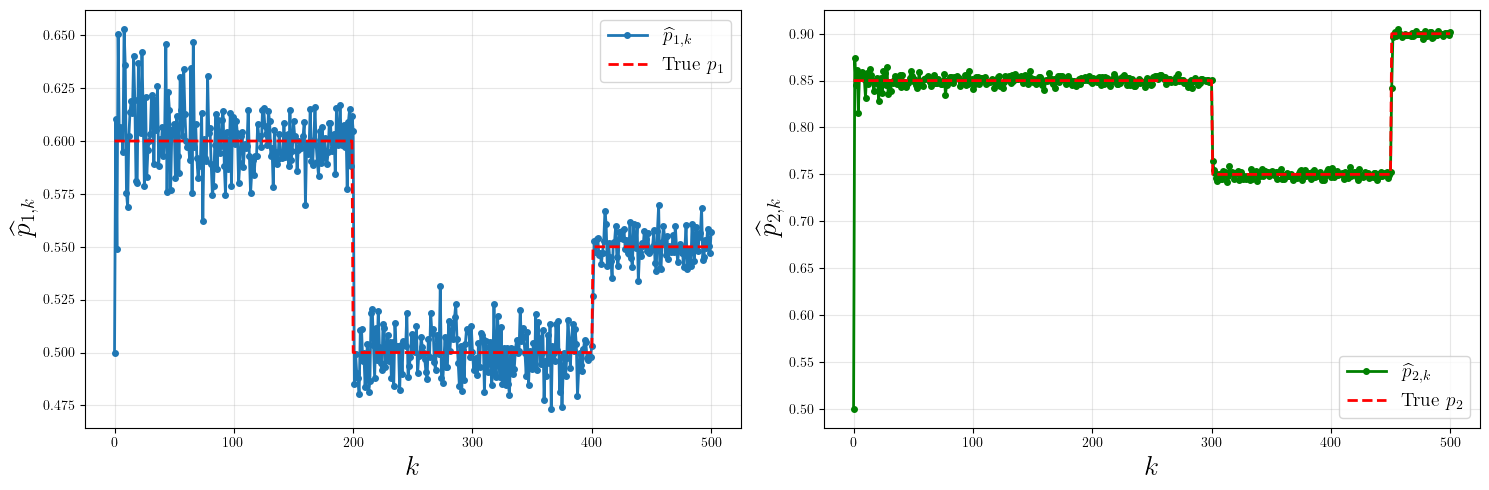

In [5]:
p1_est = [e[0] for e in estimates_hist_tp]
p2_est = [e[1] for e in estimates_hist_tp]
p1_true_vals = [t[0] for t in p_true_hist_tp]
p2_true_vals = [t[1] for t in p_true_hist_tp]
iterations = range(len(p1_est))

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(iterations, p1_est, 'o-', linewidth=2, markersize=4, label=r'$\widehat{p}_{1,k}$')
ax1.plot(iterations, p1_true_vals, 'r--', linewidth=2, label=r'True $p_1$')
ax1.set_xlabel(r'$k$', fontsize=20)
ax1.set_ylabel(r'$\widehat{p}_{1,k}$', fontsize=20)
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(iterations, p2_est, 'o-', linewidth=2, markersize=4, color='green', label=r'$\widehat{p}_{2,k}$')
ax2.plot(iterations, p2_true_vals, 'r--', linewidth=2, label=r'True $p_2$')
ax2.set_xlabel(r'$k$', fontsize=20)
ax2.set_ylabel(r'$\widehat{p}_{2,k}$', fontsize=20)
ax2.legend(fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_changing_p_time.png', dpi=300)
plt.show()